In [1]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import datetime
import math
from scipy import stats

In [22]:
amazon_sales = pd.read_csv("../Datasets/amazon_final_NO_OHE.csv")

In [5]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(amazon_sales)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,7717,0,object,7717
1,product_rating,7717,0,float64,31
2,total_reviews,7717,0,float64,3984
3,purchased_last_month,7717,0,int64,30
4,original_price,7717,0,float64,3061
5,is_best_seller,7717,0,object,11
6,is_sponsored,7717,0,object,2
7,coupon,7717,0,object,42
8,buy_box_availability,7717,0,int64,2
9,sustainability_tags,7717,0,int64,2


## 1. Preparación del dataset

### Voy a eliminar las columnas que considero que no me ofrecen valor para el estudio estadístico

In [6]:
amazon_sales.drop(columns=[ 'product_image_url'], inplace=True)
info = info_df(amazon_sales)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,7717,0,object,7717
1,product_rating,7717,0,float64,31
2,total_reviews,7717,0,float64,3984
3,purchased_last_month,7717,0,int64,30
4,original_price,7717,0,float64,3061
5,is_best_seller,7717,0,object,11
6,is_sponsored,7717,0,object,2
7,coupon,7717,0,object,42
8,buy_box_availability,7717,0,int64,2
9,sustainability_tags,7717,0,int64,2


In [8]:
# Análisis estadístico detallado de amazon_sales

# 1. ESTADÍSTICAS DESCRIPTIVAS POR VARIABLE
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 80)
print(amazon_sales.describe())

# 2. ANÁLISIS POR SEGMENTOS
print("\n" + "=" * 80)
print("ANÁLISIS POR SEGMENTO DE PRODUCTO")
print("=" * 80)
for segmento in amazon_sales['product_segment'].unique():
    print(f"\n{segmento}:")
    print(amazon_sales[amazon_sales['product_segment'] == segmento][['original_price', 'product_rating', 'purchased_last_month']].describe())

# 3. ANÁLISIS POR CATEGORÍA
print("\n" + "=" * 80)
print("PRECIOS PROMEDIO POR CATEGORÍA")
print("=" * 80)
categoria_stats = amazon_sales.groupby('product_category')[['original_price', 'product_rating', 'purchased_last_month']].agg(['mean', 'median', 'std', 'count'])
print(categoria_stats)

# 4. CORRELACIÓN DE VARIABLES NUMÉRICAS
print("\n" + "=" * 80)
print("MATRIZ DE CORRELACIÓN")
print("=" * 80)
numeric_cols = ['product_rating', 'total_reviews', 'purchased_last_month', 'original_price', 'discount_percentage', 'log_original_price', 'log_purchased_last_month', 'log_total_reviews']
print(amazon_sales[numeric_cols].corr())

# 5. ANÁLISIS DE DISTRIBUCIONES
print("\n" + "=" * 80)
print("ANÁLISIS DE SIMETRÍA Y CURTOSIS")
print("=" * 80)
for col in numeric_cols:
    skewness = amazon_sales[col].skew()
    kurtosis = amazon_sales[col].kurtosis()
    print(f"{col:30} | Skewness: {skewness:7.3f} | Kurtosis: {kurtosis:7.3f}")

# 6. ANÁLISIS DE CATEGORÍAS
print("\n" + "=" * 80)
print("DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 80)
print("\nBest Seller:")
print(amazon_sales['is_best_seller'].value_counts())
print("\nPatrocinio:")
print(amazon_sales['is_sponsored'].value_counts())
print("\nTiene Cupón:")
print(amazon_sales['has_coupon'].value_counts())
print("\nBuy Box Availability:")
print(amazon_sales['buy_box_availability'].value_counts())

# 7. ANÁLISIS DE OUTLIERS
print("\n" + "=" * 80)
print("ANÁLISIS DE OUTLIERS (IQR)")
print("=" * 80)
for col in numeric_cols:
    Q1 = amazon_sales[col].quantile(0.25)
    Q3 = amazon_sales[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = amazon_sales[(amazon_sales[col] < lower_bound) | (amazon_sales[col] > upper_bound)]
    print(f"{col:30} | Outliers: {len(outliers):5d} ({100*len(outliers)/len(amazon_sales):.2f}%)")

# 8. RELACIONES CLAVE
print("\n" + "=" * 80)
print("ANÁLISIS DE RELACIONES CLAVE")
print("=" * 80)
print("\nPrecio promedio por Best Seller:")
print(amazon_sales.groupby('is_best_seller')['original_price'].agg(['mean', 'median', 'std']))
print("\nPrecio promedio por Patrocinio:")
print(amazon_sales.groupby('is_sponsored')['original_price'].agg(['mean', 'median', 'std']))
print("\nCompras promedio por Best Seller:")
print(amazon_sales.groupby('is_best_seller')['purchased_last_month'].agg(['mean', 'median']))
print("\nRating promedio por Patrocinio:")
print(amazon_sales.groupby('is_sponsored')['product_rating'].agg(['mean', 'median', 'std']))

ESTADÍSTICAS DESCRIPTIVAS
       product_rating  total_reviews  purchased_last_month  original_price  \
count     7717.000000    7717.000000           7717.000000     7717.000000   
mean         4.427679    6285.944020           1299.501101      233.071840   
std          0.468086   25262.306539           4865.931978      437.952888   
min          0.000000       0.000000              0.000000        2.160000   
25%          4.300000     191.000000            100.000000       32.990000   
50%          4.500000     910.000000            400.000000       97.000000   
75%          4.700000    3816.000000           1000.000000      230.450000   
max          5.000000  865598.000000         100000.000000     5449.000000   

       buy_box_availability  sustainability_tags   has_coupon  \
count           7717.000000          7717.000000  7717.000000   
mean               0.709861             0.097577     0.021122   
std                0.453856             0.296761     0.143801   
min        

In [7]:
amazon_sales.is_best_seller.value_counts()

is_best_seller
No Badge             7339
Best Seller           195
Amazon's              158
Limited time deal      17
Ends in                 2
Save 77%                1
Save 17%                1
Save 30%                1
Save 12%                1
Save 18%                1
Save 10%                1
Name: count, dtype: int64

In [7]:
amazon_sales.product_category.value_counts()

product_category
Other Electronics      8755
Laptops                8693
Phones                 6563
Cameras                3677
Power & Batteries      2877
TV & Display           2630
Chargers & Cables      1833
Storage                1630
Speakers               1345
Networking             1070
Headphones              997
Printers & Scanners     877
Gaming                  809
Smart Home              465
Wearables               454
Name: count, dtype: int64

### De cara a un análisis estadístico de características de productos, me conviene hacerlo por categorías, me quedaré con la categoría más grande (LAPTOPS: productos relacionados)

# OBJETIVO:

### Lo que pretendo estudiar en este proyecto final son las características de ciertos productos de amazon y como estas influyen en el precio y entre ellas mismas.

# 1. Gráficas sobre las variables relevantes individuales.
- Laptops ( Categoría de "Laptops", productos relacionados)

Haré uso de gráficas aprendidas en la asignatura de Data Vizualitation

- Graficaré las características que me parecen más relevantes en la elección del precio de los productos

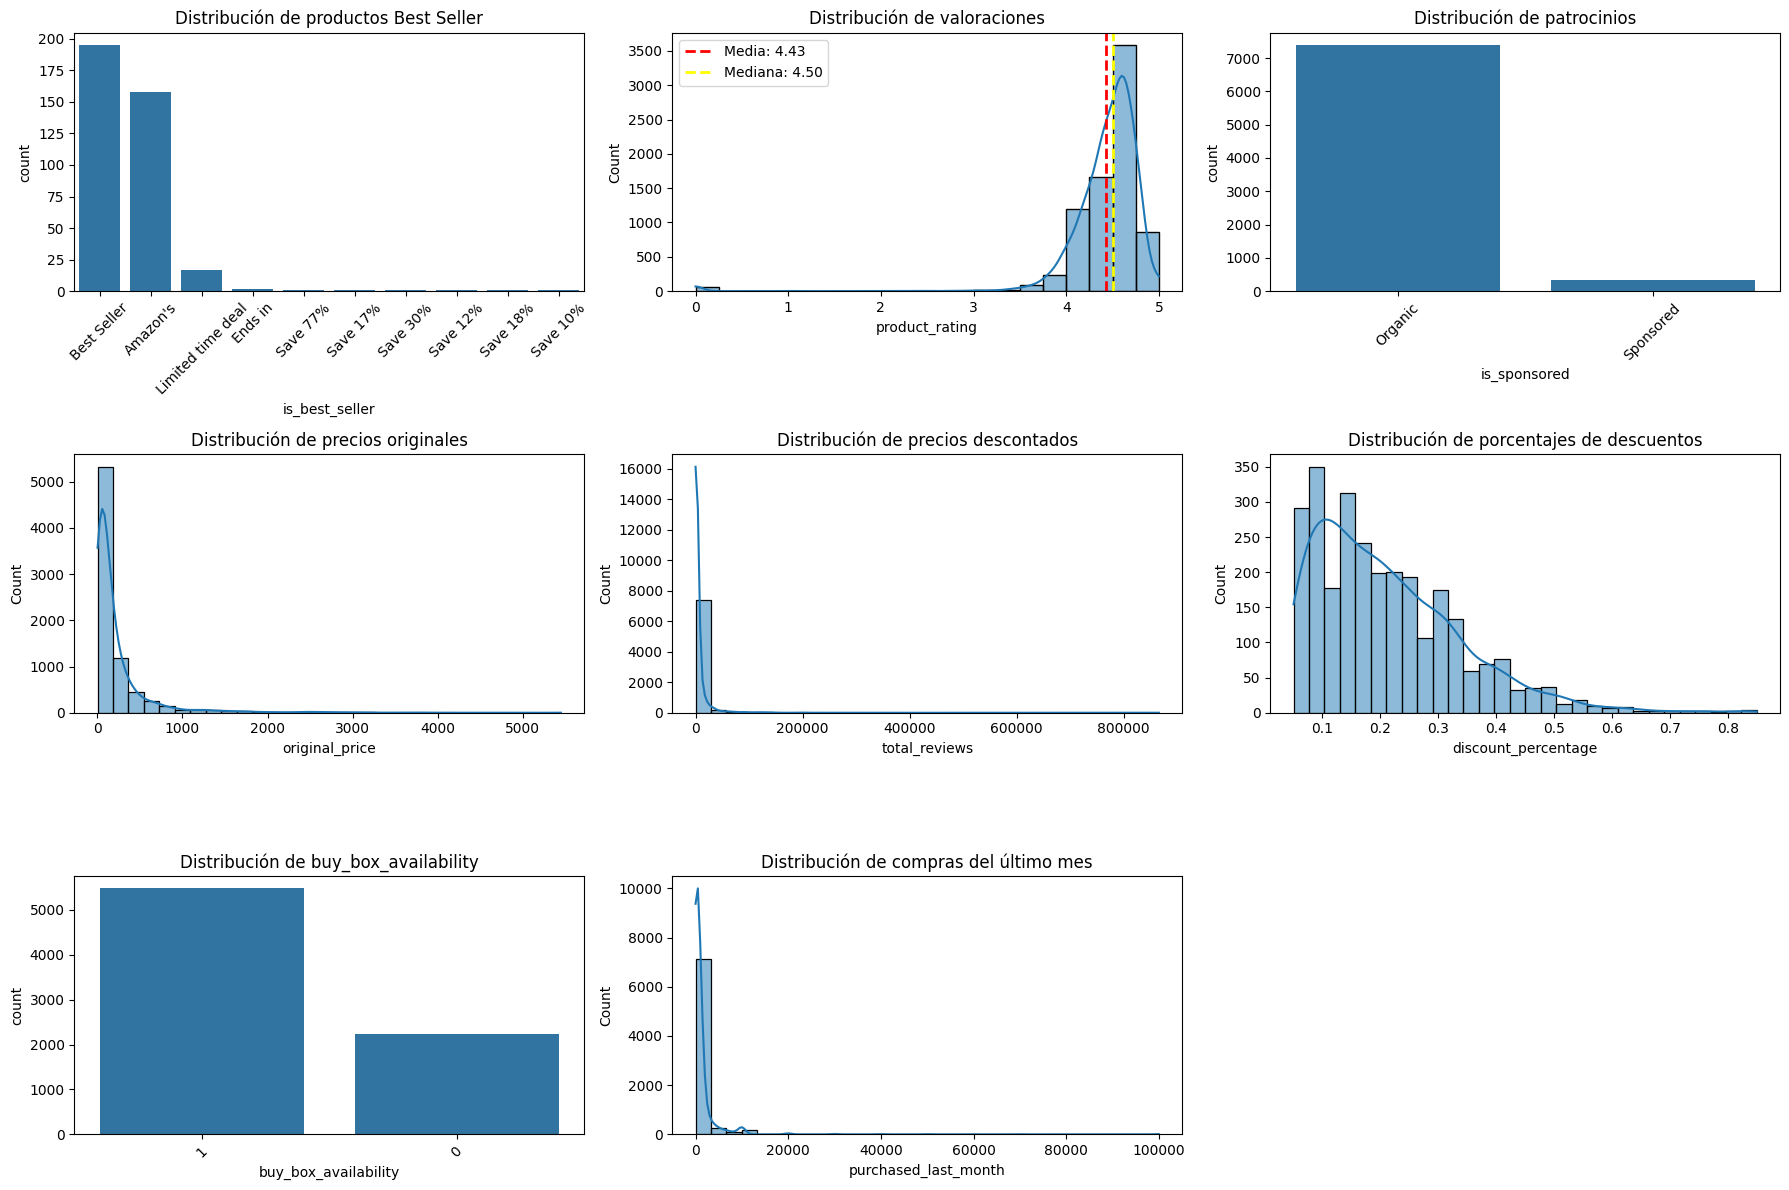

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Subset without 'No Badge'
amazon_sin_NoBadge = amazon_sales[amazon_sales['is_best_seller'] != 'No Badge']

# FIGURA DE 3 FILAS X 3 COLUMNAS
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# Distribución de los valores de best seller
ax = axes[0][0]
sns.countplot(
    data=amazon_sin_NoBadge,
    x='is_best_seller',
    order=amazon_sin_NoBadge['is_best_seller'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de productos Best Seller')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

# Distribución de las valoraciones
ax = axes[0][1]
sns.histplot(
    amazon_sales['product_rating'].dropna(),
    bins=20, kde=True, ax=ax
)
valoracion_media = amazon_sales.product_rating.mean()
ax.axvline(valoracion_media, color='red', linestyle='--', linewidth=2, label=f'Media: {valoracion_media:.2f}')
valoracion_mediana = amazon_sales.product_rating.median()
ax.axvline(valoracion_mediana, color='yellow', linestyle='--', linewidth=2, label=f'Mediana: {valoracion_mediana:.2f}')
ax.legend()
ax.set_title('Distribución de valoraciones')
ax.set_visible(True)

# Distribución de patrocinios
ax = axes[0][2]
sns.countplot(
    data=amazon_sales,
    x='is_sponsored',
    order=amazon_sales['is_sponsored'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de patrocinios')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

# Distribución de precios originales
ax = axes[1][0]
sns.histplot(
    amazon_sales['original_price'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de precios originales')
ax.set_visible(True)

# Distribución de precios descontados
ax = axes[1][1]
sns.histplot(
    amazon_sales['total_reviews'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de precios descontados')
ax.set_visible(True)

# Distribución de porcentajes de descuentos
ax = axes[1][2]
sns.histplot(
    amazon_sales[amazon_sales['discount_percentage'] > 0].discount_percentage.dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de porcentajes de descuentos')
ax.set_visible(True)

# Distribución de buy_box_availability
ax = axes[2][0]
amazon_sales_copy = amazon_sales.copy()
amazon_sales_copy['buy_box_availability'] = amazon_sales_copy['buy_box_availability'].fillna('No')
sns.countplot(
    data=amazon_sales_copy,
    x='buy_box_availability',
    order=amazon_sales_copy['buy_box_availability'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de buy_box_availability')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

# Distribución de compras del último mes
ax = axes[2][1]
sns.histplot(
    amazon_sales['purchased_last_month'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de compras del último mes')
ax.set_visible(True)

axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()


- Distribución de productos Best Seller: He mostrado la gráfica sin el valor "No Badge" ya que en comparación, el resto de valores se quedaban sin representación. No_badge representa a 8350 productos, sin tenerlo en cuenta, vemos que la etiqueta de productos con la etiqueta Amazon's representa el grupo más poblado, por detrás tenemos los que tienen la etiqueta de tiempo limitado, etiqueta de más vendido y etiquetas de descuendos. Más tarde, analizaré como estas etiquetas influyen al precio

- Distribución de las valoraciones de los productos: esta distribucion nos permite ver como la media de los productos tienen un 4.33 de media en valoraciones, además, vemos como en general los productos de la categoría Laptops están valorados por encima del 4.4 y vemos pocos valores muy bajos

- Distribución de patrocinios: Se observa como la mayoría de productos, no están patrocinados. Más tarde comprobaré cómo de significativo es que esén patrocinados

- Distribución de precios: Se puede apreciar como la mayoría de productos se encuentran en el rango de de 0-500€, a continuación veré el BoxPlot para ver como se organizan los datos y ver los outliers mejor.

- Distribución de porcentajes de descuentos: Vemos algunos al 75% de descuento aproximadamente y otros por encima del 50% sin embargo, la distribución se reparte mayormente entre el 5% y el 50% de descuento





# 2. OUTLIERS Y RELACIONES ENTRE VARIABLES

Realizando las gráficas de las variables individuales ya he tenido indicios de cuales son los outliers de cada una, de hecho he tenido que filtrar algunas distribuciones para eliminar los outliers de ellas, a continuación los analizaré detalladamente

In [24]:
import plotly.express as px
fig = px.box(amazon_sales, x="product_rating", y='is_sponsored',width=1000, height=500)
fig.show()


- Product rating: En el histograma he apreciado una serie de outliers, en esta ocasión he querido mostrar, además a qué tipo de producto, si patrocinado o no, correponden cada valoraciones. Podemos ver como los productos que no están patrocinados, tienen menos outliers pero los que tiene, son mucho más bajos, que los outliers de aquellos productos patrocinados. Más adelante estudiaré la relación entre variables, pero puedo ir viendo un poco la relación entre las valoraciones y el patrocinio del producto.

In [25]:
import plotly.express as px
fig = px.box(amazon_sales, x="original_price", y='is_sponsored',width=1000, height=500)
fig.show()

In [26]:
import plotly.express as px
fig = px.box(amazon_sales, x="original_price", y='buy_box_availability',width=1000, height=500)
fig.show()

- Original price: Como la categoría Laptops, está formada por todo tipo de productos, no solo portátiles como tal, tenemos outliers altos que corresponden a los portátiles como tal, tenemos muchos productos de bajo coste (cables, pilas...) y por eso tenemos esos outliers

In [27]:
import plotly.express as px
fig = px.box(amazon_sales[amazon_sales.discount_percentage > 0] , x="discount_percentage",width=1000, height=500)
fig.show()

- discount_percentage:
- Mínimo descuento: 4.53
- El 25% de los productos con descuento tiene un descuento menor o igual a 10.27%
- La mediana es 23.34% de descuento, además la vemos desplazada hacia el Q3, esto nos dice que hay algo de asimetría hacia la izquierda de la distribución y por lo tanto, dentro del rango intercuartílico, los descuentos están más concentrados en la parte alta.
- El 75% de los productos con descuento tiene un descuento menor o igual que 31.83%
- Observamos como hasta el límite superior tenemos más valores que entre el inferior y el Q1, por lo tanto, fuera de la zona intercuartílica hay más descuentos altos.
- Tenemos tres valores considerados outliers (73.33, 75.85, 77.33)

In [28]:
import plotly.express as px
fig = px.box(amazon_sales , x="total_reviews",width=1000, height=500)
fig.show()

- Observo como el rango intercuartílico se encuentra entre las 27000 y las 111000 Reseñas, tenemos tres productos 'TopVentas' que pasan de estos límites

In [14]:
import plotly.express as px

fig = px.box(Laptops, x="purchased_last_month",width=1000, height=500)
fig.update_layout(width=1000,height=500)
fig.show()

In [15]:
import plotly.express as px

fig = px.box(Laptops, x="purchased_last_month", y='is_sponsored',width=1000, height=500)
fig.update_layout(width=1000,height=500)
fig.show()

In [29]:
import plotly.express as px
fig = px.box(amazon_sales, x="purchased_last_month",y='is_sponsored',width=1000, height=500)
fig.show()


- Aquí tenemos datos muy dispersos con un intervalo muy ancho. Por lo tanto he decidido separar entre Patrocinados y Orgánicos para ver la relación con las ventas, además he filtrado los outliers más altos para poder ver la relación en ventas por debajo de 10000
- Se puede intuir que los productos patrocinados tienen muchas más ventas que los Orgánicos, en la gráfica podemos ver como el 75% de los productos tiene 1000 o menos ventas mientras que los orgánicos este valor son 200

# 3. TESTS



In [17]:
from tqdm import tqdm
import pandas as pd

def boot(data):
    veces = 10000   # número de medias a generar
    muestra = 300   # tamaño de cada muestra
    medias_rating = []

    for i in tqdm(range(veces)):
        muestra_i = data.sample(muestra, replace=True)   # with replacement
        medias_rating.append(muestra_i.mean())

    df_boot = pd.DataFrame({"medias": medias_rating})
    return df_boot

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

def paint(data):
    plt.figure(figsize=(8,5))
    sns.histplot(data, kde=True, bins=30)
    plt.title("Distribución de medias bootstrap de product_rating")
    plt.xlabel("Media del rating (muestras de tamaño 300)")
    plt.show()

    stats.probplot(data, dist="norm", plot=plt)
    plt.title("QQ-Plot medias bootstrap product_rating")
    plt.show()

In [ ]:
from scipy import stats
# Aplicar el test de Shapiro-Wilk

def test_normalidad(test,grupo):
    stat, p = test(grupo)

    print("Estadístico:", stat)
    print("p-valor:", p)

    if p < 0.05:
        print("Los datos NO siguen una distribución normal.")
    else:
        print("Los datos podrían seguir una distribución normal...o no")

## 3.1 ¿ Existe una diferencia singificativa entre la valoración de los productos patrocinados y los orgánicos ?

### En el estudio de outliers ya he podido comprobar como podría haber diferencias entre las valoraciones de los productos patrocinados y los que no están patrocinados.

## NORMALIDAD DE PRODUCT_RATING

100%|██████████| 10000/10000 [00:02<00:00, 4531.84it/s]


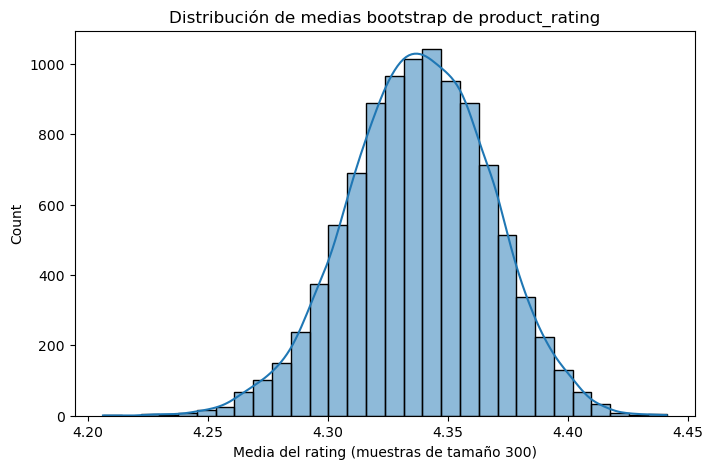

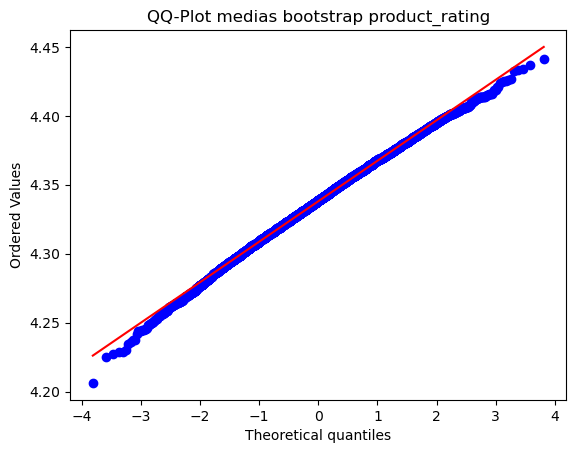

In [20]:
data = Laptops['product_rating'].dropna()

df_boot = boot(data)

paint(df_boot["medias"])

In [21]:
test_normalidad(stats.shapiro,df_boot["medias"])

Estadístico: 0.9986793509591496
p-valor: 2.3049043408898214e-07
Los datos NO siguen una distribución normal.


c:\Users\USER\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



In [22]:
test_normalidad(stats.normaltest,df_boot["medias"])

Estadístico: 36.00411142356425
p-valor: 1.5198703454443464e-08
Los datos NO siguen una distribución normal.


- Primero estudiaremos las diferencias de sus varianzas con el test de Levene (Sin asumir normalidad)


In [23]:
import numpy as np
from scipy import stats

# Creamos dos grupos con varianzas distintas
grupo1 = Laptops[Laptops.is_sponsored == 'Sponsored'].product_rating.dropna()
grupo2 = Laptops[Laptops.is_sponsored == 'Organic'].product_rating.dropna()

# Verificamos si las varianzas son realmente diferentes con la prueba de Levene
stat, p_var = stats.levene(grupo1, grupo2)
print(f"Prueba de Levene (varianza): p-value = {p_var:.4f}. Estadístico: {stat:.4f}")

Prueba de Levene (varianza): p-value = 0.5247. Estadístico: 0.4046


In [24]:
grupo1.std(), grupo2.std()

(0.5028978985462478, 0.504866621757502)

- No podemos afirmar que las varianzas sean diferentes (Estadísticamente podrían ser iguales)

- Por lo tanto haré el Test de Mann-Whitney U para estudiar la diferencia de sus medias. Usaré este test ya que no puedo asumir normalidad de los datos de las valoraciones

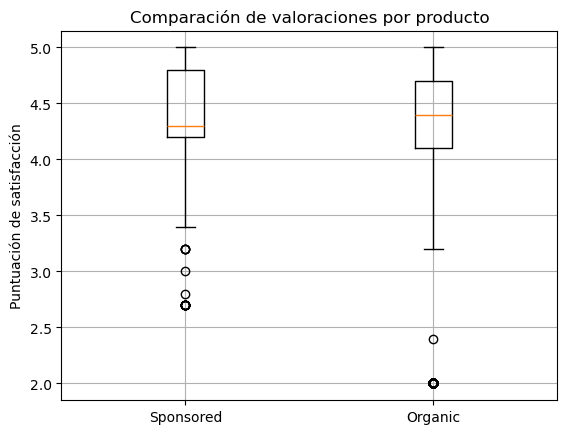

Estadístico U: 1647984.00
Valor p: 0.1499
No se detecta una diferencia significativa.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Simulamos dos grupos con distribuciones diferentes
grupo1 = Laptops[Laptops.is_sponsored == 'Sponsored'].product_rating.dropna()
grupo2 = Laptops[Laptops.is_sponsored == 'Organic'].product_rating.dropna()

# Gráfico de cajas
plt.boxplot([grupo1, grupo2], labels=["Sponsored", "Organic"])
plt.title("Comparación de valoraciones por producto")
plt.ylabel("Puntuación de satisfacción")
plt.grid(True)
plt.show()

# Prueba de Mann-Whitney U
stat, p = mannwhitneyu(grupo1, grupo2, alternative='two-sided')

print(f"Estadístico U: {stat:.2f}")
print(f"Valor p: {p:.4f}")

if p < 0.05:
    print("Hay una diferencia significativa en la valoración de los productos.")
else:
    print("No se detecta una diferencia significativa.")

- No podemos afirmar que las valoraciones sean significativamente diferentes dependiendo del producto patrocinado o no

## 3.2 ¿ Existe una diferencia significativa entre las ventas de los productos patrocinados y los que no ?

In [26]:
Laptops[Laptops.is_sponsored == 'Sponsored'].purchased_last_month.mean(), Laptops[Laptops.is_sponsored == 'Organic'].purchased_last_month.mean()

(2097.357723577236, 454.0544771446462)

### Parece que los patrocinados se han venido mucho más en el último mes

## NORMALIDAD DE PURCHASED_LAST_MONTH

100%|██████████| 10000/10000 [00:01<00:00, 6261.16it/s]


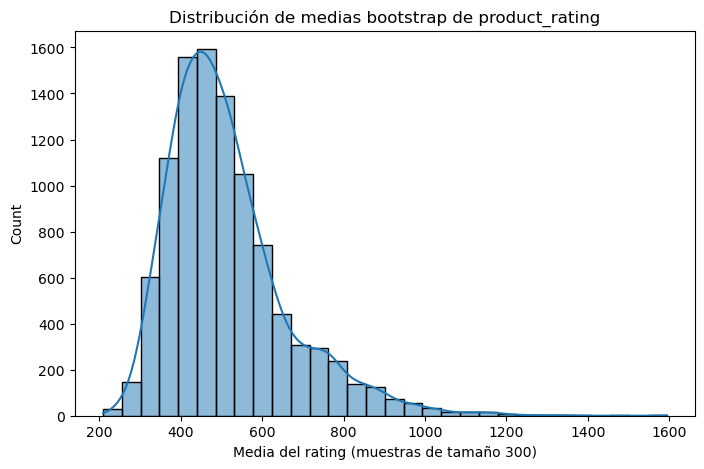

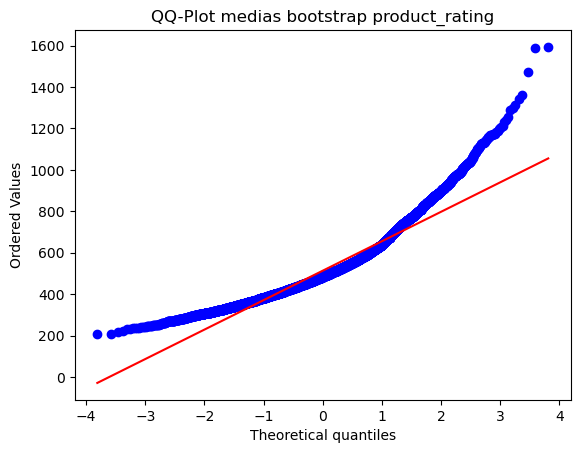

In [27]:
data = Laptops['purchased_last_month'].dropna()

df_boot = boot(data)

paint(df_boot["medias"])

In [28]:
test_normalidad(stats.shapiro,df_boot["medias"])

Estadístico: 0.9142866248525332
p-valor: 2.0418599078561168e-59
Los datos NO siguen una distribución normal.


c:\Users\USER\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



In [29]:
test_normalidad(stats.normaltest,df_boot["medias"])

Estadístico: 2495.2315266806963
p-valor: 0.0
Los datos NO siguen una distribución normal.


### - No puedo asumir su normalidad

## VARIANZAS

In [30]:
Laptops[Laptops.is_sponsored == 'Sponsored'].purchased_last_month.dropna().std(), Laptops[Laptops.is_sponsored == 'Organic'].purchased_last_month.dropna().std()

(3604.2552982807733, 2496.5673941571695)

In [31]:
import numpy as np
from scipy import stats

# Creamos dos grupos con varianzas distintas

grupo1 = Laptops[Laptops.is_sponsored == 'Sponsored'].purchased_last_month.dropna()
grupo2 = Laptops[Laptops.is_sponsored == 'Organic'].purchased_last_month.dropna()

# Verificamos si las varianzas son realmente diferentes con la prueba de Levene
stat, p_var = stats.levene(grupo1, grupo2)
print(f"Prueba de Levene (varianza): p-value = {p_var:.4f}. Estadístico: {stat:.4f}")

Prueba de Levene (varianza): p-value = 0.0000. Estadístico: 92.4942


### Lo que nos dice la prueba de Levene es que las varianzas NO son iguales

- Por lo tanto aplicaré el test de Welch, usado como la prueba t de Student para variables de varianza desigual

In [32]:
import numpy as np
from scipy import stats

# Aplicamos la prueba de Welch (t-test con varianzas desiguales)
t_stat, p_value = stats.ttest_ind(grupo1, grupo2, equal_var=False)

print(f"\nPrueba de Welch:")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación del resultado
alpha = 0.05
if p_value < alpha:
    print("Las medias son significativamente diferentes.")
else:
    print("No hay evidencia suficiente para afirmar que las medias son diferentes.")


Prueba de Welch:
Estadístico t: 7.0859
Valor p: 0.0000
Las medias son significativamente diferentes.


### Una vez realizados las pruebas necesarias, puedo afirmar que la diferencia de las ventas entre productos Patrocinados y Orgánicos es estadísticamente significativa

## 3.3 ¿Existe alguna relación entre el patrocinio (o no) y la etiqueta de best_seller?

- ### Dividiré entre aquellos que tienen etiqueta de best seller y los que no

In [33]:
Laptops.is_best_seller.value_counts()

is_best_seller
No Badge             8350
Amazon's              141
Limited time deal      71
Save 10%               61
Best Seller            42
Save 12%               26
Save 77%                2
Name: count, dtype: int64

In [34]:
len(Laptops[Laptops.is_best_seller != 'No Badge'])

343

In [35]:
Laptops[['is_best_seller', 'is_sponsored']]

,is_best_seller,is_sponsored
1,No Badge,Sponsored
2,No Badge,Sponsored
10,Best Seller,Organic
11,Best Seller,Organic
17,Best Seller,Organic
...,...,...
42652,No Badge,Organic
42653,Limited time deal,Organic
42657,No Badge,Organic
42661,No Badge,Organic


In [36]:
tabla_observada = pd.crosstab(Laptops["is_best_seller"], Laptops["is_sponsored"])
n = tabla_observada.sum().sum()
print("Total Elementos", n)
tabla_observada

Total Elementos 8693


is_sponsored,Organic,Sponsored
is_best_seller,,
Amazon's,109,32
Best Seller,29,13
Limited time deal,67,4
No Badge,7795,555
Save 10%,61,0
Save 12%,0,26
Save 77%,0,2


In [37]:
print(Laptops["is_best_seller"].unique())
Laptops["is_best_seller"].value_counts(normalize=True)

['No Badge' 'Best Seller' "Amazon's" 'Limited time deal' 'Save 12%'
 'Save 77%' 'Save 10%']


is_best_seller
No Badge             0.960543
Amazon's             0.016220
Limited time deal    0.008167
Save 10%             0.007017
Best Seller          0.004831
Save 12%             0.002991
Save 77%             0.000230
Name: proportion, dtype: float64

In [38]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Ver la tabla de frecuencias observada
tabla_observada = pd.crosstab(Laptops["is_best_seller"], Laptops["is_sponsored"])
print("Tabla de Frecuencias Observada:\n", tabla_observada)

# Calcular el test de Chi-cuadrado
chi2, p, dof, tabla_esperada = chi2_contingency(tabla_observada)

# Mostrar resultados
print(f"Valor p: {p}")

# Interpretación del resultado
alpha = 0.05
if p < alpha:
    print("\nRechazamos la hipótesis nula: Existe una asociación significativa entre la etiqueta de best_seller y el patrocinio")
else:
    print("\nNo se puede rechazar la hipótesis nula: No se encontró asociación significativa entre la etiqueta de best_seller y el patrocinio")


Tabla de Frecuencias Observada:
 is_sponsored       Organic  Sponsored
is_best_seller                       
Amazon's               109         32
Best Seller             29         13
Limited time deal       67          4
No Badge              7795        555
Save 10%                61          0
Save 12%                 0         26
Save 77%                 0          2
Valor p: 2.098905897798296e-94

Rechazamos la hipótesis nula: Existe una asociación significativa entre la etiqueta de best_seller y el patrocinio


### El test χ² indica una asociación altamente significativa entre ser Sponsored y la presencia de etiquetas promocionales o de calidad (Amazon’s Choice, Best Seller, Save %...).

### En otras palabras, la distribución de etiquetas es distinta entre Sponsored y Organic.
### Los productos patrocinados presentan una mayor proporción de badges positivos (Amazon’s Choice, Best Seller, Save%), mientras que los productos orgánicos tienden a no tener ningún badge.

# 4. CORRELACIONES

### Estudiando los outliers también grafiqué ciertas relaciones entre pares de variables

In [39]:
import plotly.express as px
fig = px.scatter(Laptops, x='product_rating', y='original_price', title="Scatter Plot con Plotly")
fig.show()
df = Laptops.groupby('product_rating')['original_price'].mean()
fig = px.scatter(df, x=df.index, y=df.values, title="Scatter Plot con Plotly")
fig.show()

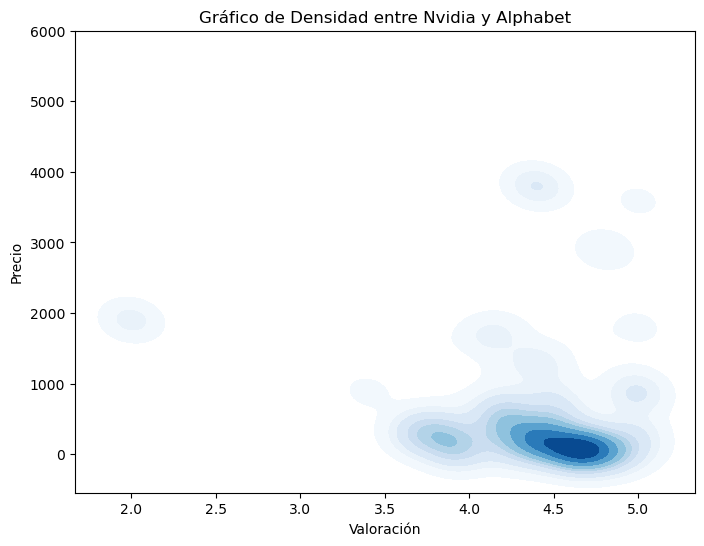

In [40]:
import seaborn as sns

# Gráfico de densidad para ver la relación entre BBVA y Santander
plt.figure(figsize=(8, 6))
sns.kdeplot(x='product_rating', y='original_price', data=Laptops, fill=True, cmap="Blues")
plt.title('Gráfico de Densidad entre Nvidia y Alphabet')
plt.xlabel('Valoración')
plt.ylabel('Precio')
plt.show()

### Parece que hay muchos productos que no superan los 1000 €

In [41]:
v = Laptops.groupby(['is_sponsored', 'is_best_seller'])['purchased_last_month'].sum().reset_index()
v.pivot(index='is_best_seller', columns='is_sponsored', values='purchased_last_month')

is_sponsored,Organic,Sponsored
is_best_seller,,
Amazon's,55750.0,63700.0
Best Seller,407200.0,130000.0
Limited time deal,4750.0,200.0
No Badge,2432800.0,320750.0
Save 10%,0.0,NaN
Save 12%,NaN,1300.0
Save 77%,NaN,0.0


- ### Ventas en el último mes dependiendo de su etiqueta de best_seller y sponsored

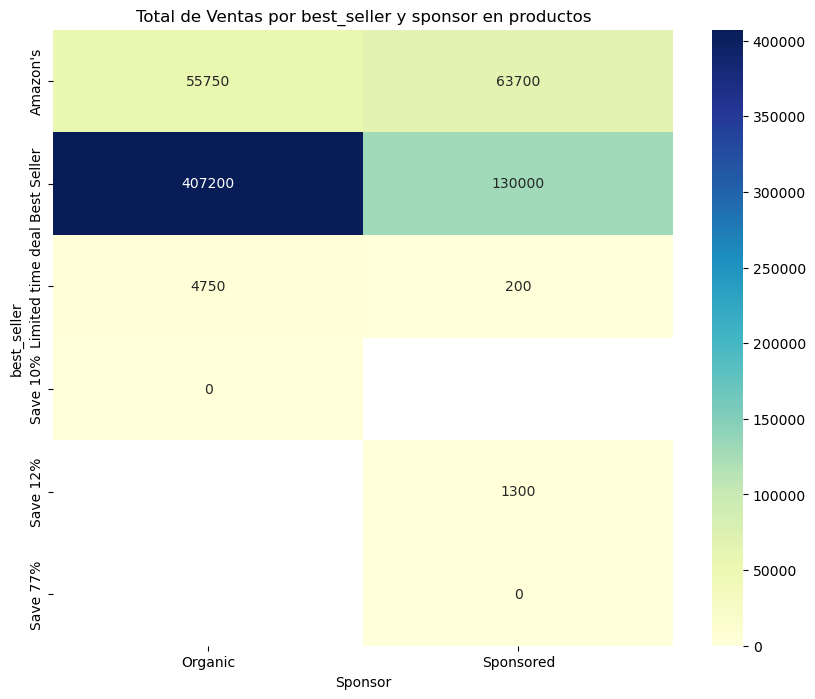

In [42]:
ventas_por_sponsored = lap_sin_NoBadge.groupby(['is_sponsored', 'is_best_seller'])['purchased_last_month'].sum().reset_index()
# ventas_por_sponsored = ventas_por_sponsored.sort_values('N.Mes')

# Formato ancho
ventas_pivot = ventas_por_sponsored.pivot(index='is_best_seller', columns='is_sponsored', values='purchased_last_month')
# ventas_pivot.columns = ventas_por_sponsored.drop_duplicates(subset=['N.Mes'])['MES']

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(ventas_pivot, annot=True, fmt=".0f", cmap="YlGnBu")

# Añadir título y etiquetas
plt.title('Total de Ventas por best_seller y sponsor en productos')
plt.xlabel('Sponsor')
plt.ylabel('best_seller')
plt.show()

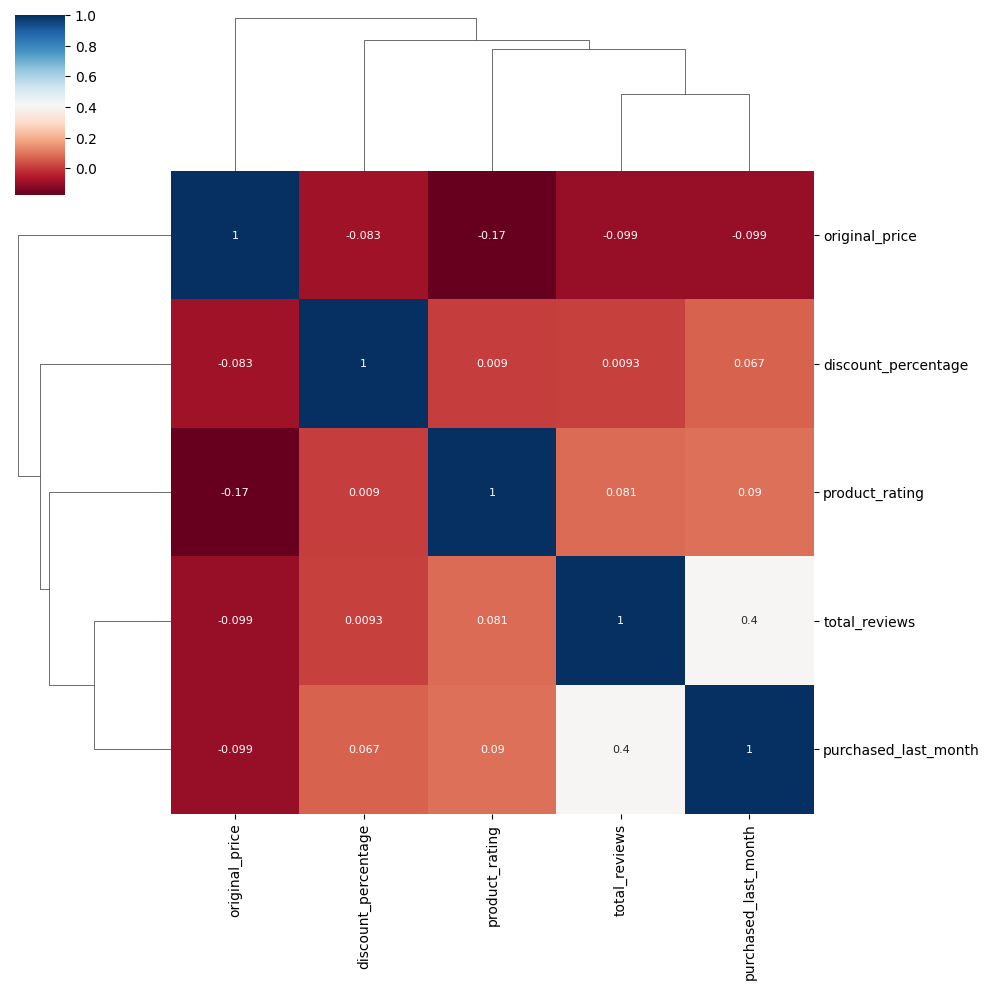

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.clustermap(amazon_sales[['product_rating', 'total_reviews', 'purchased_last_month', 'original_price', 'discount_percentage']].corr(),
                   method = 'complete',
                   cmap   = 'RdBu',
                   annot  = True,
                   annot_kws = {'size': 8})

- total_reviews y ventas en el último mes: Podemos apreciar una correlación positiva entre el número de reviews y las ventas en el último mes, esto tiene mucho sentido ya que a más ventas, más personas pondrán una review al producto.
- discounted price y original price: Son prácticamente iguales o directamente proporcionales
- discount_percentage y discounted_price : cuanto más alto es el porcentaje de descuento, más bajo es el precio descontado
- original price/discounted_price y product_rating: a más alto el precio, menor tenderá a ser la valoración del producto

# 5. REGRESIÓN

- preprocesamiento

In [55]:
Laptops.loc[Laptops['sustainability_tags'].notna(), 'sustainable'] = 'sustainable'
Laptops.loc[Laptops['sustainability_tags'].isna(), 'sustainable'] = 'no_sustainable'

In [56]:
Laptops.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8693 entries, 1 to 42669
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         8693 non-null   object 
 1   product_rating        8108 non-null   float64
 2   total_reviews         8108 non-null   float64
 3   purchased_last_month  6634 non-null   float64
 4   discounted_price      7997 non-null   float64
 5   original_price        7997 non-null   float64
 6   is_best_seller        8693 non-null   object 
 7   is_sponsored          8693 non-null   object 
 8   has_coupon            8693 non-null   object 
 9   buy_box_availability  8693 non-null   object 
 10  sustainability_tags   983 non-null    object 
 11  product_category      8693 non-null   object 
 12  discount_percentage   7997 non-null   float64
 13  sustainable           8693 non-null   object 
 14  log_price             7997 non-null   float64
 15  log_reviews           810

### Voy a hacer una primera versión, seguramente los outliers, los valores desproporcionados dentro de las reviews y las ventas hagan que el modelo considere esas características mucho más importantes, y haya que usar algún otro tipo de refresión logarítmica o normalizar los valores

In [57]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# 1. Definir tus variables (Numéricas y Categóricas mezcladas)
# Ajusta esta lista con las columnas que tú quieras probar
features = ['total_reviews','product_rating', 'purchased_last_month', 'is_best_seller', 'has_coupon', 'is_sponsored', 'buy_box_availability','sustainable']
target = 'original_price'

# Filtramos primero para asegurarnos de que no hay Nulos en estas columnas específicas
# (Si hay nulos, la regresión fallará)
df_clean = Laptops.dropna(subset=features + [target]).copy()

# 2. Transformar Categóricas a Numéricas (Get Dummies)
# drop_first=True es CRUCIAL para regresiones lineales (evita redundancia)
X = pd.get_dummies(df_clean[features], drop_first=True, dtype=int)
y = df_clean[target]

# Muestra cómo quedó X para que entiendas la transformación
print("Así se ven las columnas ahora (primeras 3 filas):")
display(X.head(3))

# # 3. El código de tu profesor (Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# # 4. Generar el modelo (OLS)
# # Añadimos la constante (intercepto)
X_train_sm = sm.add_constant(X_train)

# # Ajustamos el modelo
model = sm.OLS(y_train, X_train_sm).fit()

# # 5. Ver los resultados
print(model.summary())

# # Para predecir en el test (Opcional, si lo necesitas)
X_test_sm = sm.add_constant(X_test)
y_pred = model.predict(X_test_sm)

Así se ven las columnas ahora (primeras 3 filas):


,total_reviews,product_rating,purchased_last_month,is_best_seller_Best Seller,is_best_seller_Limited time deal,is_best_seller_No Badge,is_best_seller_Save 12%,has_coupon_Save $1.00 with coupon,has_coupon_Save $1.50 with coupon,has_coupon_Save $100.00 with coupon,...,has_coupon_Save $69.00 with coupon,has_coupon_Save $8.00 with coupon,has_coupon_Save $90.00 with coupon,has_coupon_Save 10% with coupon,has_coupon_Save 15% with coupon,has_coupon_Save 20% with coupon,has_coupon_Save 5% with coupon,is_sponsored_Sponsored,buy_box_availability_No,sustainable_sustainable
1,2457.0,4.3,6000.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3044.0,4.6,2000.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
10,865598.0,4.7,100000.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


                            OLS Regression Results                            
Dep. Variable:         original_price   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     72.66
Date:                Fri, 12 Dec 2025   Prob (F-statistic):          1.64e-305
Time:                        11:57:07   Log-Likelihood:                -40880.
No. Observations:                5434   AIC:                         8.181e+04
Df Residuals:                    5409   BIC:                         8.198e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


### Conclusiones del Análisis de Regresión

**1. Evaluación del Modelo**
Hemos conseguido explicar el **24.4% de la varianza del precio** ($R^2 = 0.244$). Aunque el modelo es estadísticamente significativo, este porcentaje nos indica que el precio depende en gran medida de factores que no están en el dataset, como la **fuerza de la marca** o las especificaciones técnicas.

**2. Conclusiones de Negocio**
El análisis de las variables nos ha revelado patrones claros del mercado:
* **Comportamiento de Rating:** Existe una relación inversa entre precio y valoración. Los usuarios son mucho más críticos con los productos caros, mientras que tienden a valorar mejor los productos económicos que cumplen su función.
* **Ley de la Demanda:** Se confirma que los productos con mayor volumen de ventas (`purchased_last_month`) suelen ser los de menor precio.
* **Estrategia de Cupones:** Los cupones de alto valor (ej. $100) funcionan como un indicador exclusivo de productos "Premium".
* **Reviews irrelevantes para el precio:** La cantidad de reseñas no influye en el precio; un producto puede ser viral y barato, o viral y caro.

**3. Limitaciones y Mejora**
El análisis de residuos muestra que el modelo predice bien en gamas medias y bajas, pero pierde precisión con los **productos de ultra-lujo** (outliers). Para futuros análisis, sería recomendable segmentar los productos por gama o incluir la variable "Marca" para mejorar la capacidad predictiva.

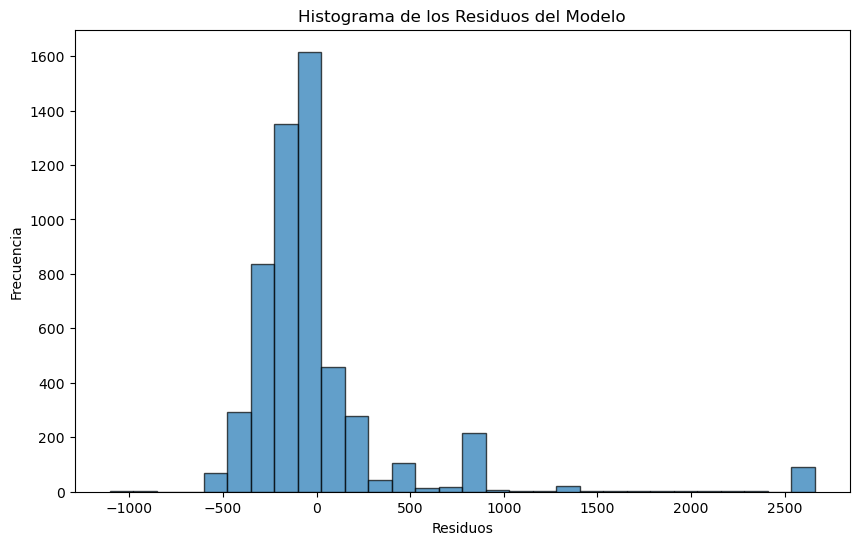

In [58]:
import matplotlib.pyplot as plt

# Calcular los residuos del modelo
residuals = model.resid

# Crear el histograma de los residuos
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.title("Histograma de los Residuos del Modelo")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

In [59]:
import plotly.graph_objects as go
import numpy as np

# 1. Crear la figura base
fig = go.Figure()

# 2. Agregar la línea de "Predicción Perfecta" (Diagonal)
# Esto equivale al "Plano del modelo" de tu profesor, pero en N-dimensiones
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

fig.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode='lines',
    line=dict(color='green', width=3, dash='dash'),
    name='Predicción Perfecta (Ideal)'
))

# 3. Agregar los puntos (Valor Real vs Predicción)
fig.add_trace(go.Scatter(
    x=y_test,
    y=y_pred,
    mode='markers',
    marker=dict(size=6, color='blue', opacity=0.7),
    text=[f"Real: {r:.2f}<br>Pred: {p:.2f}" for r, p in zip(y_test, y_pred)],
    name='Datos del Test'
))

# 4. (Opcional) Dibujar las líneas de error para los primeros 50 puntos
# (No dibujamos todos para no saturar el gráfico)
limit = 50
for real, pred in zip(y_test[:limit], y_pred[:limit]):
    fig.add_trace(go.Scatter(
        x=[real, real],
        y=[real, pred],
        mode='lines',
        line=dict(color='red', width=1),
        showlegend=False
    ))

# 5. Diseño
fig.update_layout(
    title="Comparación: Precio Real vs. Precio Predicho",
    xaxis_title="Precio Real (Original Price)",
    yaxis_title="Precio que predijo el modelo",
    width=900,
    height=700,
    template="plotly_white"
)

fig.show()

In [60]:
# Variables para los ejes (Elige las dos numéricas más fuertes)
x_axis = X_test['product_rating']
y_axis = X_test['purchased_last_month']

fig = go.Figure()

# 1. Puntos REALES (Azul)
fig.add_trace(go.Scatter3d(
    x=x_axis,
    y=y_axis,
    z=y_test,
    mode='markers',
    marker=dict(size=4, color='blue', opacity=0.6),
    name="Precio Real"
))

# 2. Puntos PREDICHOS (Naranja)
fig.add_trace(go.Scatter3d(
    x=x_axis,
    y=y_axis,
    z=y_pred,
    mode='markers',
    marker=dict(size=4, color='orange', opacity=0.8),
    name="Precio Predicho"
))

# 3. Líneas de error (Unen el punto real con el predicho)
# Hacemos solo una muestra de 100 puntos para que el navegador no se cuelgue
sample_indices = range(0, len(X_test), int(len(X_test)/100)) 

for i in sample_indices:
    # Necesitamos acceder a los valores por posición usando iloc
    x_val = x_axis.iloc[i]
    y_val = y_axis.iloc[i]
    z_real = y_test.iloc[i]
    z_pred = y_pred.iloc[i]
    
    fig.add_trace(go.Scatter3d(
        x=[x_val, x_val],
        y=[y_val, y_val],
        z=[z_real, z_pred],
        mode='lines',
        line=dict(color='red', width=2),
        showlegend=False
    ))

fig.update_layout(
    title="Predicción 3D: Rating vs Ventas vs Precio",
    scene=dict(
        xaxis_title="Rating",
        yaxis_title="Ventas Mes",
        zaxis_title="Precio ($)"
    ),
    width=900,
    height=700
)

fig.show()

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calcular el Bias
bias = np.mean(y_pred - y_test)

# Calcular el Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calcular el Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test,y_pred)

print("Bias:", bias)
print("MAE:", mae)
print("RMSE:", rmse)
print("r^2:",r2)

Bias: 20.37938239855338
MAE: 223.9309708224464
RMSE: 367.30804283517773
r^2: 0.3989297742541622


- ### La mayoría de mis predicciones son razonables, pero tengo unos cuantos productos muy caros donde mi modelo falla estrepitosamente, disparando el error cuadrático
- ### El precio suele ser más alto que el que predice

---
### He buscado información sobre qué hacer en estos casos y he encontrado un método par convertir esas características en escala logarítmica

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# 1. Definir tus variables (Numéricas y Categóricas mezcladas)
# Ajusta esta lista con las columnas que tú quieras probar

Laptops['log_price'] = np.log1p(Laptops['original_price'])
Laptops['log_reviews'] = np.log1p(Laptops['total_reviews'])
Laptops['log_purchased'] = np.log1p(Laptops['purchased_last_month'])

features = ['log_reviews','product_rating', 'log_purchased', 'is_best_seller', 'has_coupon', 'is_sponsored', 'buy_box_availability','sustainable']
target = 'log_price'

# Filtramos primero para asegurarnos de que no hay Nulos en estas columnas específicas
# (Si hay nulos, la regresión fallará)
df_clean = Laptops.dropna(subset=features + [target]).copy()

# 2. Transformar Categóricas a Numéricas (Get Dummies)
# drop_first=True es CRUCIAL para regresiones lineales (evita redundancia)
X = pd.get_dummies(df_clean[features], drop_first=True, dtype=int)
y = df_clean[target]

# # 3. El código de tu profesor (Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# # 4. Generar el modelo (OLS)
# # Añadimos la constante (intercepto)
X_train_sm = sm.add_constant(X_train)

# # Ajustamos el modelo
model = sm.OLS(y_train, X_train_sm).fit()

# # 5. Ver los resultados
print(model.summary())

# # Para predecir en el test (Opcional, si lo necesitas)
X_test_sm = sm.add_constant(X_test)
y_pred = model.predict(X_test_sm)

Así se ven las columnas ahora (primeras 3 filas):


C:\Users\USER\AppData\Local\Temp\ipykernel_21444\3786542709.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\USER\AppData\Local\Temp\ipykernel_21444\3786542709.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\USER\AppData\Local\Temp\ipykernel_21444\3786542709.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

,log_reviews,product_rating,log_purchased,is_best_seller_Best Seller,is_best_seller_Limited time deal,is_best_seller_No Badge,is_best_seller_Save 12%,has_coupon_Save $1.00 with coupon,has_coupon_Save $1.50 with coupon,has_coupon_Save $100.00 with coupon,...,has_coupon_Save $69.00 with coupon,has_coupon_Save $8.00 with coupon,has_coupon_Save $90.00 with coupon,has_coupon_Save 10% with coupon,has_coupon_Save 15% with coupon,has_coupon_Save 20% with coupon,has_coupon_Save 5% with coupon,is_sponsored_Sponsored,buy_box_availability_No,sustainable_sustainable
1,7.807103,4.3,8.699681,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,8.021256,4.6,7.601402,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
10,13.671177,4.7,11.512935,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.532
Method:                 Least Squares   F-statistic:                     258.4
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        11:57:07   Log-Likelihood:                -7091.9
No. Observations:                5434   AIC:                         1.423e+04
Df Residuals:                    5409   BIC:                         1.440e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


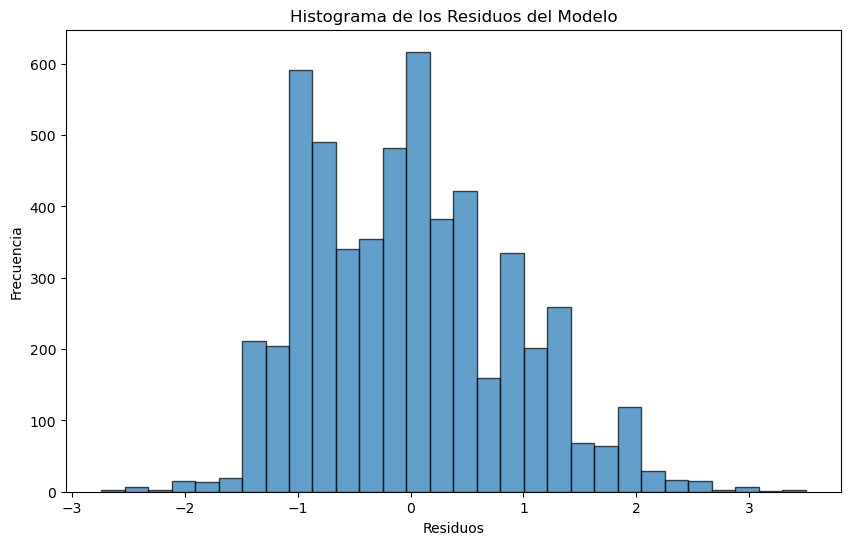

In [63]:
# Calcular los residuos del modelo
residuals = model.resid

# Crear el histograma de los residuos
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.title("Histograma de los Residuos del Modelo")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

In [64]:
import plotly.graph_objects as go
import numpy as np

# 1. Crear la figura base
fig = go.Figure()

# 2. Agregar la línea de "Predicción Perfecta" (Diagonal)
# Esto equivale al "Plano del modelo" de tu profesor, pero en N-dimensiones
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

fig.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode='lines',
    line=dict(color='green', width=3, dash='dash'),
    name='Predicción Perfecta (Ideal)'
))

# 3. Agregar los puntos (Valor Real vs Predicción)
fig.add_trace(go.Scatter(
    x=y_test,
    y=y_pred,
    mode='markers',
    marker=dict(size=6, color='blue', opacity=0.7),
    text=[f"Real: {r:.2f}<br>Pred: {p:.2f}" for r, p in zip(y_test, y_pred)],
    name='Datos del Test'
))

# 4. (Opcional) Dibujar las líneas de error para los primeros 50 puntos
# (No dibujamos todos para no saturar el gráfico)
limit = 50
for real, pred in zip(y_test[:limit], y_pred[:limit]):
    fig.add_trace(go.Scatter(
        x=[real, real],
        y=[real, pred],
        mode='lines',
        line=dict(color='red', width=1),
        showlegend=False
    ))

# 5. Diseño
fig.update_layout(
    title="Comparación: Precio Real vs. Precio Predicho",
    xaxis_title="Precio Real (Original Price)",
    yaxis_title="Precio que predijo el modelo",
    width=900,
    height=700,
    template="plotly_white"
)

fig.show()

### Además habría que hacer una limpieza de outliers, en este modelo tampoco estoy teniendo en cuenta marcas, las cuales serían muy útiles para esos proudctos de marcas con precios altísimos

### Comparativa Final: Modelo Lineal vs. Modelo Logarítmico (Definitivo)

Tras detectar problemas de normalidad y outliers, decidí aplicar una transformación logarítmica tanto al precio como a las variables de volumen (ventas y reviews). Los resultados confirman que el mercado se comporta de forma multiplicativa.

#### 1. Tabla Resumen de Mejora

| Métrica | Modelo 1 (Lineal) | Modelo 3 (Log-Log) | Cambio |
| :--- | :--- | :--- | :--- |
| **Precisión ($R^2$)** | 24.4% | **53.4%** | **+29 puntos** (Más del doble) |
| **Calidad (AIC)** | ~81,800 | **~14,230** | El error se ha minimizado drásticamente |
| **Ventas y Reviews** | Poca relevancia | **Muy Significativas** | Detectamos elasticidades claras |
| **Best Seller** | Irrelevante | **Determinante** | Factor clave de precio alto |

#### 2. Conclusiones Prácticas

1.  **Salto de Calidad:** Al usar logaritmos, se ha corregido la distorsión que provocaban los productos de precio extremo (outliers). Ahora el modelo explica casi la mitad de la varianza del precio ($53.4\%$), lo cual es un resultado muy robusto para datos reales de mercado.
2.  **El verdadero valor de las Reviews:** El primer modelo decía que las reviews no importaban. El modelo mejorado nos enseña la realidad: existe una **relación inversa**. Por cada 1% más de reviews, el precio baja un 0.23%. Esto confirma que los productos "virales" suelen ser artículos económicos de consumo masivo, no de lujo.
3.  **El precio de ser "Best Seller":** Hemos descubierto un patrón oculto. Al limpiar el ruido estadístico, vemos que ser *Best Seller* incrementa el precio significativamente (un 125% más caros de media). Son productos Premium que dominan su categoría.